<a href="https://colab.research.google.com/github/amulyadav1517-jpg/Customer-Segmentation/blob/main/CustomerSegmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_csv("Mall_Customers.csv")

In [ ]:
df.shape

(200, 5)

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


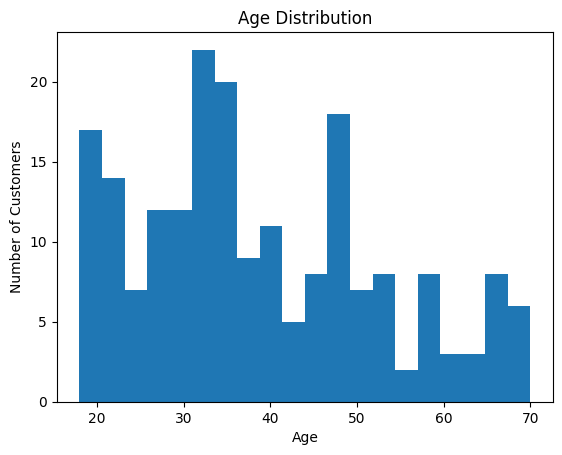

In [ ]:
#Age Distribution
plt.hist(df['Age'],bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

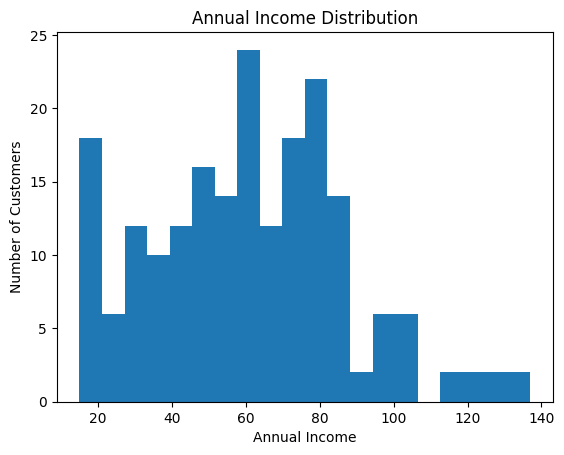

In [ ]:
#AnnualIncome Distribution

plt.hist(df['Annual Income (k$)'],bins=20)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Number of Customers")
plt.show()

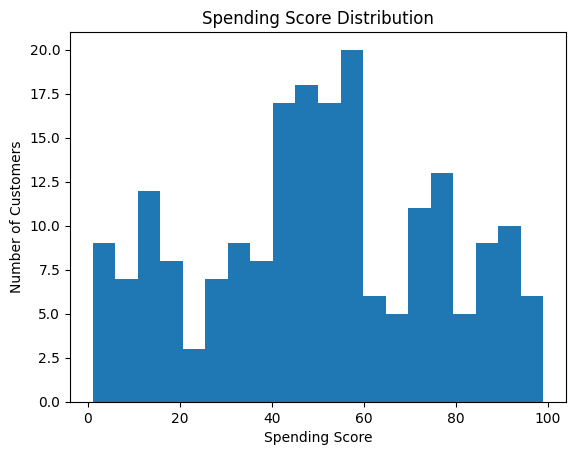

In [ ]:
plt.hist(df['Spending Score (1-100)'],bins=20)
plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:
#Feature Selection

x = df[["Spending Score (1-100)","Annual Income (k$)"]]
x

,Spending Score (1-100),Annual Income (k$)
0,39,15
1,81,15
2,6,16
3,77,16
4,40,17
...,...,...
195,79,120
196,28,126
197,74,126
198,18,137


In [ ]:
scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

In [ ]:
a = []

for i in range(1,11):

  kmeans = KMeans(n_clusters=i)
  kmeans.fit(x)

  a.append(kmeans.inertia_)

In [ ]:
a

[269981.28000000014,
 183069.17582751295,
 106348.37306211119,
 73880.64496247198,
 44448.45544793369,
 38858.959975143895,
 31676.36973205365,
 26134.99458874457,
 22824.403601237005,
 19664.68519600554]

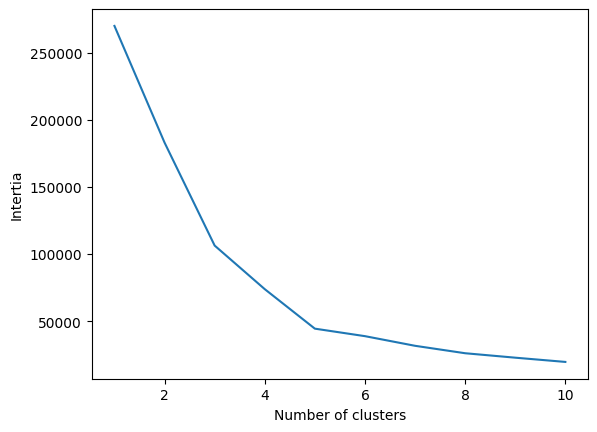

In [ ]:
plt.plot(range(1,11),a)
plt.xlabel("Number of clusters")
plt.ylabel("Intertia")
plt.show()

In [ ]:
kmeans  =KMeans(n_clusters=5)
df['Cluster'] = kmeans.fit_predict(x)

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


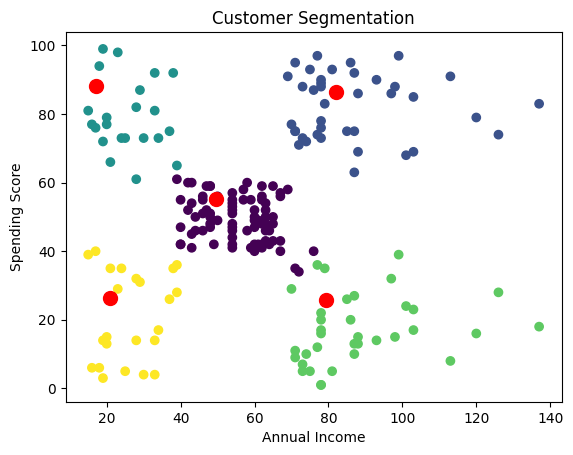

In [ ]:
plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster']
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s = 100,
    c = "red",
    marker = "o",
    label = "Centroids"

)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")
plt.show()